In [ ]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP,SELECT
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import *

from network.layer import Layer

In [ ]:
# chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
# chip.set_device_cfg(deviceType=0,IsNew32=False)
# chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=20,adc_last_gap=10)
# chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
# chip.clk_manager.set_cyc(10, 10,delay3=50)
# chip.add_compiler("../compiler/code/")

In [ ]:
chip=CHIP(PS(host="192.168.1.11", port = 7, debug=0),init=True)
# deviceType参数：0为ReRAM，1为ECRAM
# IsNew32参数：False为v1版本，True为v2版本
chip.set_device_cfg(deviceType=0,IsNew32=True)
chip.adc.set_sample_times(adc_sample_times=16)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=1000,adc_last_gap=40)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(10, 10,delay3=0)
chip.add_compiler("./compiler/code/")
chip.compensation.initop("../chip_data/chip6_/pcb_203/")

Connected to 192.168.1.11:7
local ip: 192.168.1.15 local port: 62944
正在编译文件:  ../compiler/code/asm_ds(2).txt
正在编译文件:  ../compiler/code/汇编指令解释测试.txt
编译指令 jmp_r reg2 时出错: 'COMPILER' object has no attribute 'jmp_r'


In [ ]:
# chip.adc.set_sample_times(adc_sample_times=1)

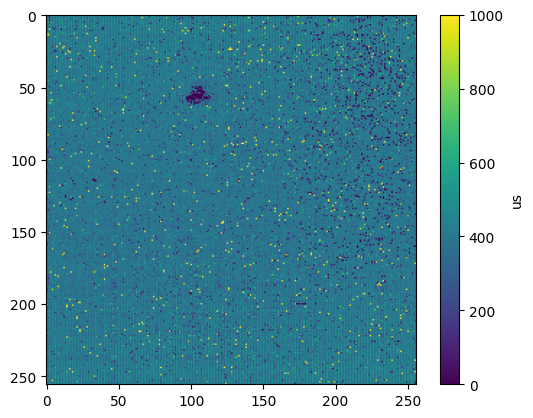

In [ ]:
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=1,row_type=0,col_type=0)
plot_cond(c,vmax=1000)

# 一、读操作

### 1. 参数说明
- Args:
    - rossbar: n*n的np矩阵
    - row_index: 行号列表
    - col_index: 列号列表
    - sub_base: 表示减去0v读的电压
    - from_row: True从行给信号，同时split_type按描述进行,False从列给信号，split_type描述中的行列互换

    - split_type: 切分方式
        - \=0,表示逐行,逐列,这个使用crossbar
        - \=1,表示逐行,列划分TIA,这个使用crossbar
        - \=2,表示开所有行,逐列,这个使用crossbar

        - \=3,表示开所有行,逐列,这个使用row_index和col_index
        - \=4,表示开所有行,列划分TIA,这个使用row_index和col_index
        - \=5,表示开所有行,所有列,这个使用row_index和col_index
        - \=6,表示逐行,逐列,这个使用row_index和col_index
        - \=7,表示逐行,列划分TIA,这个使用row_index和col_index

    

    - row_type/col_type: 表示index是怎么配置的
        - \=0,表示不使用反转,正常映射
        - \=1,表示index中01反转
        - \=2,表示只反转对应行/列所在TIA之外的所有索引

- Return:
    - 如果是逐点,则返回一个256*256的矩阵,求和则返回一个一维的256个元素的np数组

In [ ]:
# 逐点读，split_type=0，使用crossbar参数
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
plot_cond(c,vmax=1000)
# plot_cond(c[:20,:60],vmax=1000)

In [ ]:
# 并行读点，split_type=1，使用crossbar参数
crossbar = np.ones((256,256))
# v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=1,row_type=0,col_type=0)
# plot_cond(c,vmax=1000)

v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=1,row_type=0,col_type=0)
plot_cond(c,vmax=1000)

In [ ]:
# 逐列计算，split_type=2，使用crossbar参数
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=2,row_type=0,col_type=0)
# plot_cond(c,vmax=1000)

In [ ]:
# 逐列计算，split_type=3，使用row_index/col_index参数
row_index = [i for i in range(256)]
col_index = [i for i in range(256)]
v,c,r = chip.read4(crossbar=None,row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=3,row_type=0,col_type=0)
# plot_cond(c,vmax=1000)

In [ ]:
# 并行计算，split_type=4，使用row_index/col_index参数
row_index = [i for i in range(256)]
col_index = [i for i in range(256)]
v,c,r = chip.read4(crossbar=None,row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=4,row_type=0,col_type=0)
# plot_cond(c,vmax=1000)

In [ ]:
# 任意配置行列读，split_type=5，使用row_index/col_index参数，读出来的是选中的列
row_index = [i for i in range(256)]
col_index = [i for i in range(256)]
v,c,r = chip.read4(crossbar=None,row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=5,row_type=0,col_type=0)
# plot_cond(c,vmax=1000)

# 二、写操作

### 1. 参数说明
- Args:
    - rossbar: n*n的np矩阵
    - row_index: 行号列表
    - col_index: 列号列表
    - from_row: True从行给信号，同时split_type按描述进行,False从列给信号，split_type描述中的行列互换

    - split_type: 切分方式
        - \=0,表示逐行,逐列,这个使用crossbar
        - \=1,表示逐行,列划分TIA,这个使用crossbar
        - \=2,表示开所有行,逐列,这个使用crossbar

        - \=3,表示开所有行,逐列,这个使用row_index和col_index
        - \=4,表示开所有行,列划分TIA,这个使用row_index和col_index
        - \=5,表示开所有行,所有列,这个使用row_index和col_index
        - \=6,表示逐行,逐列,这个使用row_index和col_index
        - \=7,表示逐行,列划分TIA,这个使用row_index和col_index

    

    - row_type/col_type: 表示index是怎么配置的
        - \=0,表示不使用反转,正常映射
        - \=1,表示index中01反转
        - \=2,表示只反转对应行/列所在TIA之外的所有索引

In [ ]:
# 逐点set，split_type=0，使用crossbar参数
crossbar = np.ones((256,256))
chip.write4(crossbar=crossbar,row_index=None,col_index=None,write_voltage=1,tg=5,pulse_width=1e-6,set_device=True,split_type=0,row_type=0,col_type=0)

In [ ]:
# 逐点reset，split_type=0，row_type=1，表示行latch的01反转，使用crossbar参数
crossbar = np.ones((256,256))
chip.write4(crossbar=crossbar,row_index=None,col_index=None,write_voltage=1,tg=5,pulse_width=1e-6,set_device=False,split_type=0,row_type=1,col_type=0)

In [ ]:
# 并行set，split_type=5, 打开选中的行列latch, 使用row_index/col_index参数
row_index = [i for i in range(256)]
col_index = [i for i in range(256)]
chip.write4(crossbar=None,row_index=row_index,col_index=col_index,write_voltage=1,tg=5,pulse_width=1e-6,set_device=True,split_type=5,row_type=0,col_type=0)

In [ ]:
# 并行reset，split_type=5, 打开选中的行列latch,row_type=1，表示行latch的01反转, 使用row_index/col_index参数
row_index = [i for i in range(256)]
col_index = [i for i in range(256)]
chip.write4(crossbar=None,row_index=row_index,col_index=col_index,write_voltage=1,tg=5,pulse_width=1e-6,set_device=False,split_type=5,row_type=1,col_type=0)

# 三、测试读噪声

In [ ]:
crossbar = np.ones((20,180))
ans_v = []
ans_c = []
gain = 3
for i in range(100):
    print(i)
    v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=gain,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
    ans_v.append(v)
    ans_c.append(c)

np.save(f"../data/adc/pcb202/v_gain={gain}_v=0_1.npy",np.array(ans_v))
np.save(f"../data/adc/pcb202/c_gain={gain}_v=0_1.npy",np.array(ans_c))

In [ ]:
gain = 0
ans_v = np.load(f"../data/adc/pcb202/v_gain={gain}_v=0_1.npy")
ans_c = np.load(f"../data/adc/pcb202/c_gain={gain}_v=0_1.npy")
matrices = np.array(ans_v)

mean_matrix = np.mean(matrices, axis=0)[:20,:180]
var_matrix = np.var(matrices, axis=0)[:20,:180]

std_matrix = np.sqrt(var_matrix)
plot_cond(mean_matrix*1000,vmax=20,title=f"gian={gain}-mean_v",label = "mv")
plot_cond(std_matrix*1000,vmax=1,title=f"gian={gain}-std_v",label = "mv")
plot_cond(std_matrix/mean_matrix*100,vmax=10,title=f"gian={gain}-percent",label = "100%")

matrices = np.array(ans_c)

mean_matrix = np.mean(matrices, axis=0)[:20,:180]
var_matrix = np.var(matrices, axis=0)[:20,:180]
std_matrix = np.sqrt(var_matrix)
plot_cond(mean_matrix,vmax=200,title=f"gian={gain}-mean_cond")
plot_cond(std_matrix,vmax=20,title=f"gian={gain}-std_cond")
plot_cond(std_matrix/mean_matrix*100,vmax=10,title=f"gian={gain}-percent",label = "100%")